In [ ]:
import sys
import numpy as np
from pathlib import Path
from shapely.geometry import Point
from scipy.spatial import cKDTree

sys.path.append("../..")
from src.solvers.gurobi import solve_wflo_gurobi
from src.solvers.utils import save_benchmark_layout
from src.qubo_windfarm_layout.model import get_farm_area, compute_aep_from_coords
from src.qubo_windfarm_layout.evaluation import load_layout_coordinates, get_farm_area
from src.qubo_windfarm_layout.visualization import plot_gurobi_refinement, plot_selected_layout

def build_local_candidates(
    gurobi_positions,
    farm_area,
    radius_m,
    step_m,
    min_distance=396.0,
):
    gurobi_positions = np.asarray(gurobi_positions, dtype=float)

    # offset locali
    offsets_1d = np.arange(
        -radius_m,
        radius_m + step_m * 0.5,
        step_m,
    )

    dx, dy = np.meshgrid(
        offsets_1d,
        offsets_1d,
        indexing="xy",
    )

    offsets = np.column_stack([
        dx.ravel(),
        dy.ravel(),
    ])

    # tengo solo punti dentro il raggio
    offsets = offsets[
        np.linalg.norm(offsets, axis=1) <= radius_m
    ]

    # genero candidati attorno a ogni turbina Gurobi
    candidate_locations = (
        gurobi_positions[:, None, :]
        + offsets[None, :, :]
    ).reshape(-1, 2)

    # aggiungo esplicitamente le posizioni Gurobi originali
    candidate_locations = np.vstack([
        candidate_locations,
        gurobi_positions,
    ])

    # tengo solo punti dentro il farm boundary
    mask = np.array([
        farm_area.covers(Point(x, y))
        for x, y in candidate_locations
    ])

    candidate_locations = candidate_locations[mask]

    # rimuovo duplicati
    candidate_locations = np.unique(
        np.round(candidate_locations, 6),
        axis=0,
    )

    # invalid pairs
    tree = cKDTree(candidate_locations)

    invalid_pairs = tree.query_pairs(
        r=min_distance,
        output_type="ndarray",
    )

    # query_pairs include anche distanza == min_distance:
    # noi vogliamo solo < min_distance
    if len(invalid_pairs) > 0:
        d = np.linalg.norm(
            candidate_locations[invalid_pairs[:, 0]]
            - candidate_locations[invalid_pairs[:, 1]],
            axis=1,
        )

        invalid_pairs = invalid_pairs[
            d < min_distance
        ]

    return (
        candidate_locations,
        invalid_pairs.astype(np.int32),
    )


def build_local_wake_loss_matrix_optimized(
    candidate_locations,
    output_path,
    decimals=6,
):
    candidate_locations = np.asarray(
        candidate_locations,
        dtype=float,
    )

    n = len(candidate_locations)

    # 1. AEP singola turbina
    A0 = compute_aep_from_coords(
        [candidate_locations[0]]
    )

    # 2. Tutte le coppie i < j
    i_idx, j_idx = np.triu_indices(n, k=1)

    displacements = (
        candidate_locations[j_idx]
        - candidate_locations[i_idx]
    )

    # evita differenze floating tipo
    # 25.0000000001 vs 25.0
    displacements = np.round(
        displacements,
        decimals=decimals,
    )

    # 3. Canonicalizzazione:
    # (dx, dy) e (-dx, -dy) sono equivalenti
    dx = displacements[:, 0]
    dy = displacements[:, 1]

    flip = (
        (dx < 0)
        | ((dx == 0) & (dy < 0))
    )

    displacements[flip] *= -1

    # 4. Displacement unici
    unique_displacements, inverse = np.unique(
        displacements,
        axis=0,
        return_inverse=True,
    )

    print(f"Numero candidate locations: {n}")
    print(f"Numero coppie totali: {len(i_idx):,}")
    print(
        f"Numero displacement unici: "
        f"{len(unique_displacements):,}"
    )

    # 5. Physics model:
    # una sola chiamata per displacement unico
    unique_losses = np.empty(
        len(unique_displacements),
        dtype=float,
    )

    origin = np.array([0.0, 0.0])

    for k, displacement in enumerate(
        unique_displacements
    ):
        aep_pair = compute_aep_from_coords([
            origin,
            displacement,
        ])

        unique_losses[k] = max(
            0.0,
            2 * A0 - aep_pair,
        )

    # 6. Mapping verso tutte le coppie
    pair_losses = unique_losses[inverse]

    # 7. Wake-loss matrix
    L = np.zeros(
        (n, n),
        dtype=float,
    )

    L[i_idx, j_idx] = pair_losses
    L[j_idx, i_idx] = pair_losses

    if output_path is not None:
        output_path = Path(output_path)

        output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
        )

        np.savez_compressed(
        output_path,
        wake_loss_matrix=L,
        A0=A0,
        candidate_locations=candidate_locations,
        )

        print(
            f"Wake-loss data saved to: "
            f"{output_path}"
        )

    return L, A0


def get_warmstart(candidate_locations):
    warmstart_positions = np.asarray(
        load_layout_coordinates(
            STARTING_LAYOUT #"../results/layouts/gurobi_local_16_1800s_warmstart.yaml"
        ),
        dtype=float,
    )

    tree = cKDTree(candidate_locations)

    distances, indices = tree.query(
        warmstart_positions,
        k=1,
    )

    # Verifica che le posizioni del warm start esistano
    # effettivamente nella candidate grid corrente
    if np.any(distances > 1e-6):
        raise ValueError(
            f"Alcune turbine del warm start non sono nella candidate grid. "
            f"Max distance = {distances.max():.6f} m"
        )

    warm_start = np.zeros(
        len(candidate_locations),
        dtype=int,
    )

    warm_start[indices] = 1
    return warm_start

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2864483
WLS license 2864483 - registered to Accenture GmbH (Germany)


# Strategies
Faccio una prima run grezza con risoluzione tale che ho invalid pairs non nulle e wake loss migliori della baseline.
Ho scelto GRID_RESOLUTION = 128m e TIMEOUT = 30m

1) Faccio run con GRID_RESOLUTION che va come potenza di due (64 -> 32 -> 16 -> 8) e raggio uguale a 2*GRID_RESOLUTION, TIMEOUT di 30m
2) Faccio run con GRID_RESOLUTION che va come potenza di due (64 -> 32 -> 16 -> 8) e raggio uguale a 4*GRID_RESOLUTION, TIMEOUT di 30m
3) Faccio run con GRID_RESOLUTION che va come potenza di due (64 -> 32 -> 16 -> 8) e raggio uguale a 8*GRID_RESOLUTION, TIMEOUT di 30m

In [2]:
# Variables
GRID_RESOLUTION = 128
STARTING_LAYOUT = "../../results/layouts/gurobi/gurobi_128_1800s.yaml" # "../results/layouts/gurobi_local_64_2_1800s_warmstart.yaml" # "../results/layouts/gurobi/gurobi_128_1800s.yaml"
TIMEOUT = 5 # 60 * 30

# Parameters
RADIUS = 4*GRID_RESOLUTION
WAKE_LOSS_PATH = f"../../results/precomputed/wake_loss_res_{GRID_RESOLUTION}m_rad_{RADIUS}.npz"

(1795, 2)
(17979, 2)


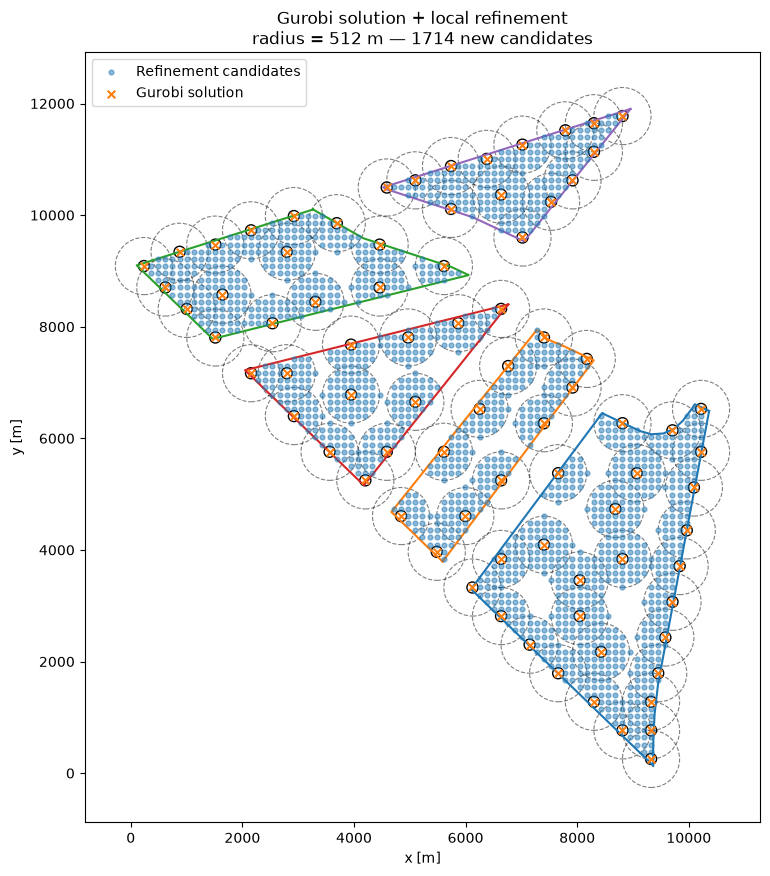

In [3]:
gurobi_positions = load_layout_coordinates(STARTING_LAYOUT)

_, farm_area = get_farm_area()

candidate_locations, invalid_pairs = build_local_candidates(
    gurobi_positions=gurobi_positions,
    farm_area=farm_area,
    radius_m=RADIUS,
    step_m=GRID_RESOLUTION,
)

print(candidate_locations.shape)
print(invalid_pairs.shape)

plot_gurobi_refinement(
    gurobi_positions=gurobi_positions,
    candidate_locations=candidate_locations,
    radius_m=RADIUS,
)

In [4]:
unique, counts = np.unique(candidate_locations, axis=0, return_counts=True)

duplicates = unique[counts > 1]

duplicates

array([], shape=(0, 2), dtype=float64)

In [6]:
wake_loss_matrix, A0 = build_local_wake_loss_matrix_optimized(
    candidate_locations,
    output_path=WAKE_LOSS_PATH
)

# wake_loss_matrix = data = np.load(WAKE_LOSS_PATH)["wake_loss_matrix"]

Numero candidate locations: 1795
Numero coppie totali: 1,610,115
Numero displacement unici: 9,216
Wake-loss data saved to: ../../results/precomputed/wake_loss_res_128m_rad_512.npz


In [ ]:


warm_start = get_warmstart(candidate_locations=candidate_locations)

Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0.05
Set parameter NonConvex to value 2
Set parameter Threads to value 1
Set parameter NodefileStart to value 0.5
Set parameter NodefileDir to value "/tmp"
Set parameter SoftMemLimit to value 28
Set parameter MIPFocus to value 0
Set parameter TimeLimit to value 5
RAM before model.optimize()
System available : 12.09 GB
System used      : 21.2%
Python process   : 0.36 GB
RAM after model.optimize()
Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (linux64 - "Ubuntu 24.04.1 LTS")

CPU model: Intel(R) Core(TM) Ultra 7 265H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 1 threads

Non-default parameters:
TimeLimit  5
SoftMemLimit  28
MIPGap  0.05
NodefileStart  0.5
NonConvex  2
Threads  1

WLS license 2864483 - registered to Accenture GmbH (Germany)
Optimize a model with 17980 rows, 1795 columns and 37753 nonzeros (Min)
Model fingerprint: 0xd06c7139
Model has 0 linear objec

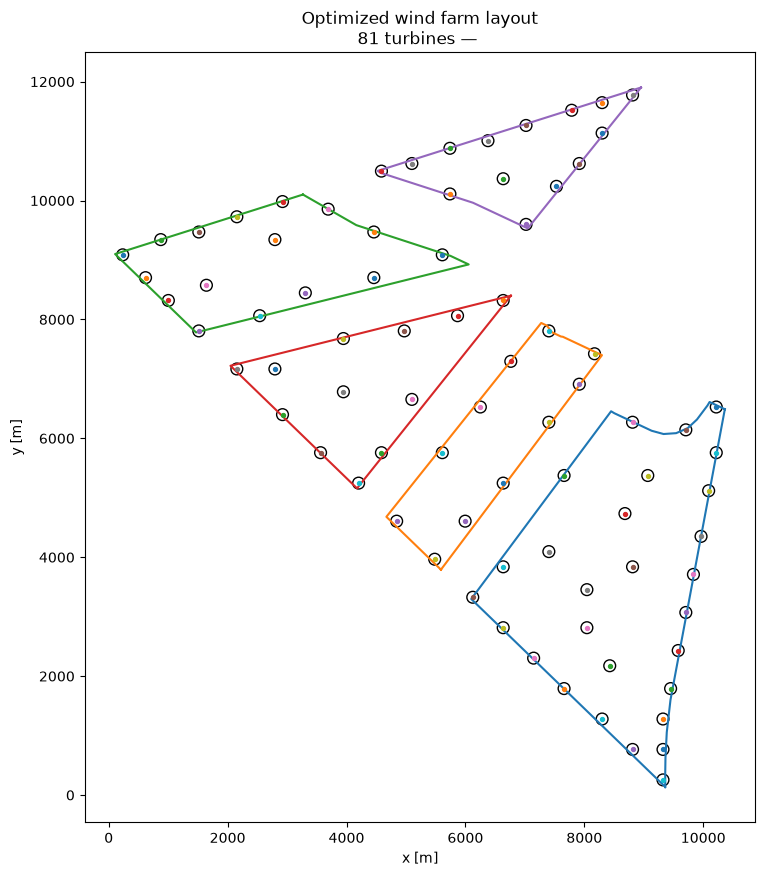

Layout saved to: /home/maicolnicolini/code/qubo-wind-farm-layout/notebooks/gurobi/../../results/layouts/gurobi/foo/gurobi_local_128_2_bis_5s_warmstart.yaml


PosixPath('/home/maicolnicolini/code/qubo-wind-farm-layout/notebooks/gurobi/../../results/layouts/gurobi/foo/gurobi_local_128_2_bis_5s_warmstart.yaml')

In [10]:
result = solve_wflo_gurobi(
    wake_loss_matrix=wake_loss_matrix,
    invalid_pairs=invalid_pairs,
    n_turbines=81,
    warm_start=warm_start,
    time_limit=TIMEOUT,
    mip_gap=0.05,
    mip_focus=0,
)

print("Objective:", result["objective"])
print("Runtime:", result["runtime"])
print("MIP gap:", result["mip_gap"])
print("Best bound:", result["best_bound"])
print("N turbines:", result["z"].sum())

selected_indices = result["selected_indices"]
selected_locations_gurobi = candidate_locations[
    selected_indices
]

plot_selected_layout(selected_locations=selected_locations_gurobi)
save_benchmark_layout(
    selected_locations=selected_locations_gurobi,
    solver_name="gurobi",
    output_dir="results/layouts/gurobi/foo",
    filename=f"gurobi_local_{GRID_RESOLUTION}_2_bis_{TIMEOUT}s_warmstart.yaml",
    grid_resolution=GRID_RESOLUTION,
)